In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
Number of samples: 303
Number of features: 13
Classes: [0 1]
=== Logistic Regression ===
Accuracy: 0.8524590163934426
Confusion Matrix:
 [[25  4]
 [ 5 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                        

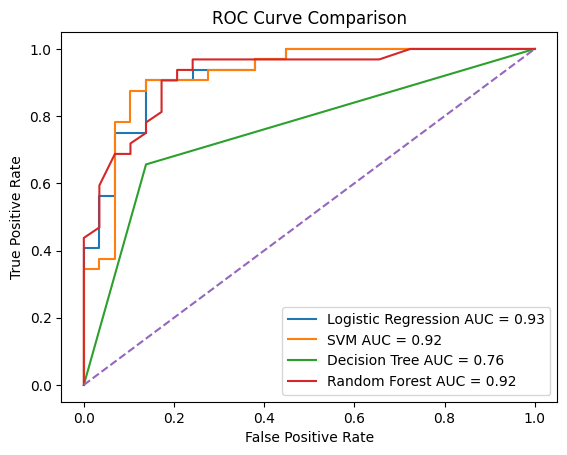


=== Comparison Table ===
                 Model  Accuracy   ROC AUC  Precision (Class 1)  \
0  Logistic Regression  0.852459  0.926724             0.870968   
1  SVM (Linear Kernel)  0.868852  0.922414             0.875000   
2        Decision Tree  0.754098  0.759159             0.840000   
3        Random Forest  0.836066  0.922414             0.843750   

   Recall (Class 1)  F1-score (Class 1)  
0           0.84375            0.857143  
1           0.87500            0.875000  
2           0.65625            0.736842  
3           0.84375            0.843750  


In [2]:
# ==========================
# 1. Load Dataset
# ==========================
data = pd.read_csv('heart.csv')
print(data.head())

X = data.drop('target', axis=1).values
y = data['target'].values

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", np.unique(y))


# ==========================
# 2. Train/Test split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==========================
# 3. Data Preprocessing (Scaling)
# ==========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================
# 4a. Logistic Regression
# ==========================
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

accuracy_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)
report_log = classification_report(y_test, y_pred_log, output_dict=True)


# ==========================
# 4b. SVM
# ==========================
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:,1]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)


# ==========================
# 4c. Decision Tree
# ==========================
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:,1]

accuracy_tree = accuracy_score(y_test, y_pred_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)
report_tree = classification_report(y_test, y_pred_tree, output_dict=True)


# ==========================
# 4d. Random Forest
# ==========================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)


# ==========================
# 5. Print Metrics
# ==========================
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_log)
print("Confusion Matrix:\n", cm_log)
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))


print("=== SVM (Linear Kernel) ===")
print("Accuracy:", accuracy_svm)
print("Confusion Matrix:\n", cm_svm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


print("=== Decision Tree ===")
print("Accuracy:", accuracy_tree)
print("Confusion Matrix:\n", cm_tree)
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))


print("=== Random Forest ===")
print("Accuracy:", accuracy_rf)
print("Confusion Matrix:\n", cm_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


# ==========================
# 6. ROC Curve Comparison
# ==========================
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)


plt.figure()

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression AUC = {roc_auc_log:.2f}')
plt.plot(fpr_svm, tpr_svm, label=f'SVM AUC = {roc_auc_svm:.2f}')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree AUC = {roc_auc_tree:.2f}')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest AUC = {roc_auc_rf:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()


# ==========================
# 7. Comparison Table
# ==========================
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM (Linear Kernel)',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_log,
        accuracy_svm,
        accuracy_tree,
        accuracy_rf
    ],
    'ROC AUC': [
        roc_auc_log,
        roc_auc_svm,
        roc_auc_tree,
        roc_auc_rf
    ],
    'Precision (Class 1)': [
        report_log['1']['precision'],
        report_svm['1']['precision'],
        report_tree['1']['precision'],
        report_rf['1']['precision']
    ],
    'Recall (Class 1)': [
        report_log['1']['recall'],
        report_svm['1']['recall'],
        report_tree['1']['recall'],
        report_rf['1']['recall']
    ],
    'F1-score (Class 1)': [
        report_log['1']['f1-score'],
        report_svm['1']['f1-score'],
        report_tree['1']['f1-score'],
        report_rf['1']['f1-score']
    ]
})

print("\n=== Comparison Table ===")
print(comparison_df)